## TAREA 1
- Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Fila @ 90%:   6 	Valor:  [0.390625]
Fila @ 90%:   15 	Valor:  [0.40429688]
Fila @ 90%:   20 	Valor:  [0.39453125]
Fila @ 90%:   21 	Valor:  [0.40039062]
Fila @ 90%:   88 	Valor:  [0.39453125]
Fila @ 90%:   98 	Valor:  [0.39257812]
Fila @ 90%:   100 	Valor:  [0.4140625]
512


(0.0, 512.0)

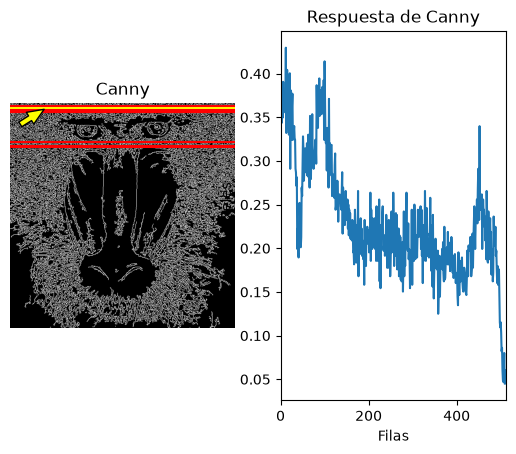

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
canny = cv2.Canny(gris, 64, 224) #prueba a jugar con umbrales (entre 0 y 255)

#Cuenta el número de píxeles blancos (255) por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de COLUMNAS, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por FILA

rows = row_counts / (255 * canny.shape[1])
fila_max = np.argmax(rows)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

# Flechita para indicar fila con máximo de pixels blancos
plt.annotate(
    '',                      # Texto vacío (solo queremos la flecha)
    xy=(80, 12),             # Coordenadas de la PUNTA de la flecha
    xytext=(20, 50),         # Coordenadas de la COLA de la flecha
    arrowprops=dict(
        facecolor='yellow',  # Color de relleno de la flecha
        edgecolor='black',   # Color del borde
        shrink=0.05,         # Espacio libre en los extremos
        width=4,             # Grosor del cuerpo de la flecha
        headwidth=10         # Ancho de la cabeza de la flecha
    )
)

# Fila con el máximo valor de píxeles blancos
plt.axhline(y=fila_max, color='yellow', linestyle='-')

# Filas con valor del 90% del máximo anterior
for i in range(0,len(rows)):
    if (rows[i] > rows[fila_max] * 0.90) & (i != fila_max):
        print("Fila @ 90%:  ", i, "\tValor: ", rows[i])
        plt.axhline(i, color='red', linestyle='-')
        
plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)

# Guardar la imagen en el disco
plt.savefig("img/tarea_1.png")
#Rango en eje "y" definido por las filas
print(canny.shape[1])
plt.xlim([0, canny.shape[0]])

## Tarea 2
 - Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobel tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

 Fuentes: 
 - Anotaciones en imagen: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html


Canny (100, 200)
Maximo nº de píxels por filas: 184; limite (90%): 165.60
Filas al 90% del máximo (5): [6, 8, 20, 24, 100]
Maximo nº de píxels por columnas: 138; limite(90%): 124.20
Columnas al 90% del máximo (3): [92, 104, 119]
Total píxeles no nulos: 34763 (13.26 %)

Sobel umbralizado (130)
Maximo nº de píxels por filas: 161; limite (90%): 144.90
Filas al 90% del máximo (7): [3, 4, 20, 51, 81, 82, 83]
Maximo nº de píxels por columnas: 179; limite(90%): 161.10
Columnas al 90% del máximo (1): [288]
Total píxeles no nulos: 31199 (11.90 %)


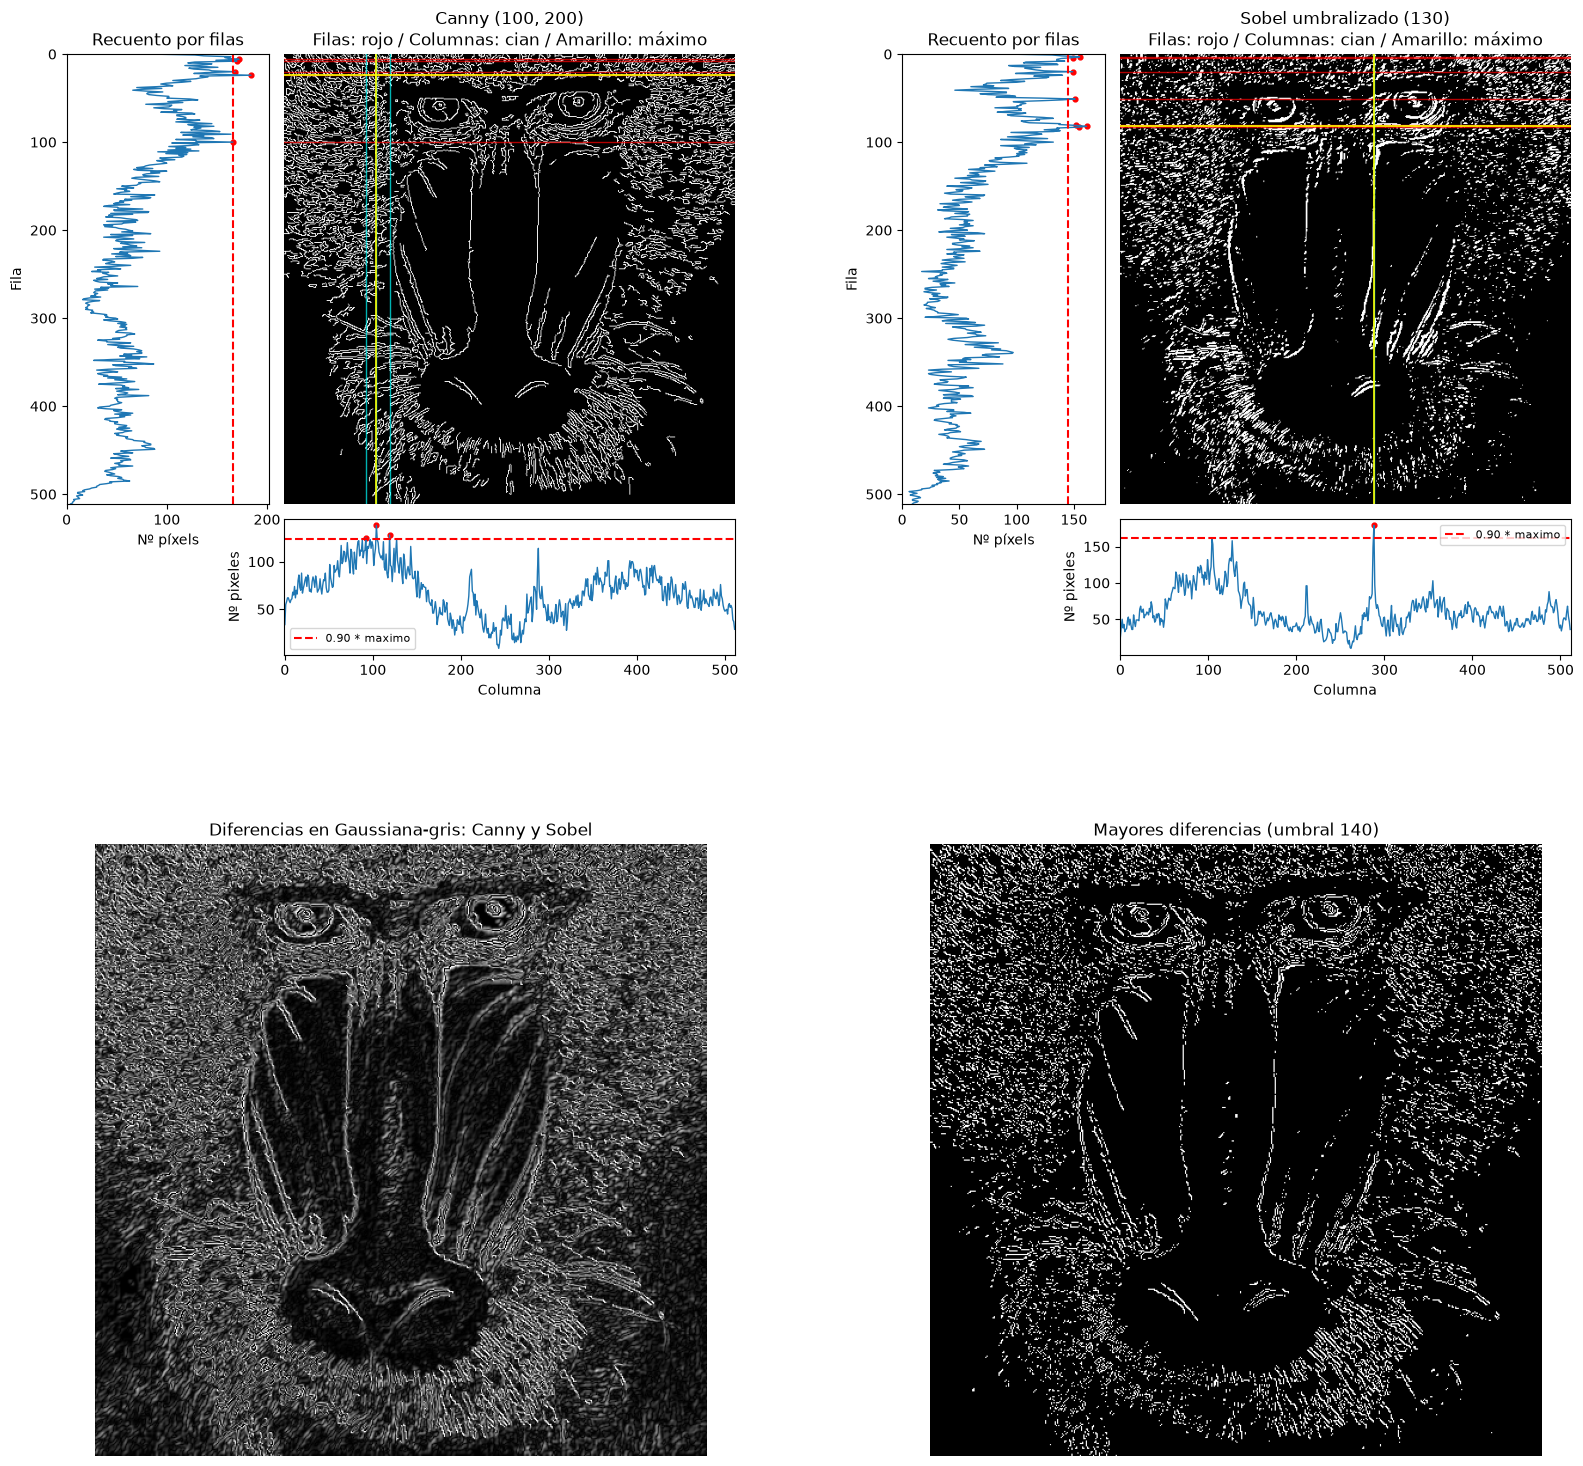

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargo imagen del mandril
mandril = cv2.imread('mandril.jpg')
if mandril is None:
    raise FileNotFoundError('No se encuentra mandril.jpg')

#Sobel 8 bits
gris = cv2.cvtColor(mandril, cv2.COLOR_BGR2GRAY)
gauss_gris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(gauss_gris, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(gauss_gris, cv2.CV_64F, 0, 1)
sobel8 = cv2.convertScaleAbs(cv2.add(sobelx, sobely))

valorUmbralSobel = 130
_, sobel_umbralizado = cv2.threshold(sobel8, valorUmbralSobel, 255, cv2.THRESH_BINARY)

canny = cv2.Canny(gauss_gris, 100, 200)

resultados = {}

from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
fig.subplots_adjust(left=0.04, right=0.98, bottom=0.06, top=0.94,
                    hspace=0.30, wspace=0.25)
for panel_titulo, (nombre, bordes) in enumerate([
    ('Canny (100, 200)', canny),
    (f'Sobel umbralizado ({valorUmbralSobel})', sobel_umbralizado)]):
    # Cuenta real de pixeles no nulos, sin dividir por el ancho o el alto.
    recuento_filas = np.count_nonzero(bordes, axis=1)
    recuento_columnas = np.count_nonzero(bordes, axis=0)

    fila_max = int(recuento_filas.max())
    col_max = int(recuento_columnas.max())
    filas = np.flatnonzero(recuento_filas > 0.90 * fila_max)
    columnas = np.flatnonzero(recuento_columnas > 0.90 * col_max)

    resultados[nombre] = dict(maxfil=fila_max, maxcol=col_max,
        filas=filas, columnas=columnas, total=int(np.count_nonzero(bordes)))
    print(f'\n{nombre}')
    print(f'Maximo nº de píxels por filas: {fila_max}; limite (90%): {0.90 * fila_max:.2f}')
    print(f'Filas al 90% del máximo ({len(filas)}): {filas.tolist()}')
    print(f'Maximo nº de píxels por columnas: {col_max}; limite(90%): {0.90 * col_max:.2f}')
    print(f'Columnas al 90% del máximo ({len(columnas)}): {columnas.tolist()}')
    print(f'Total píxeles no nulos: {np.count_nonzero(bordes)} ({100 * np.count_nonzero(bordes) / bordes.size:.2f} %)')
    
    ax_imagen = axes[0, panel_titulo]
    ax_imagen.imshow(bordes, cmap='gray', vmin=0, vmax=255)
    for y in filas:
        ax_imagen.axhline(y, color='red', linewidth=1, alpha=0.7)
    for x in columnas:
        ax_imagen.axvline(x, color='cyan', linewidth=1, alpha=0.7)
    # Posiciones de la fila y columna con más píxeles blancos.
    indice_fila_max = int(np.argmax(recuento_filas))
    indice_columna_max = int(np.argmax(recuento_columnas))

    # Dibujamos los máximos al final en amarillo para destacarlos.
    ax_imagen.axhline(indice_fila_max, color='yellow', linewidth=1.2, zorder=5)
    ax_imagen.axvline(indice_columna_max, color='yellow', linewidth=1.2, zorder=5)
    ax_imagen.set_title(f'{nombre}\nFilas: rojo / Columnas: cian / Amarillo: máximo')
    ax_imagen.axis('off')

    divisor = make_axes_locatable(ax_imagen)
    ax_filas = divisor.append_axes('left', size='45%', pad=0.15, sharey=ax_imagen)
    ax_columnas = divisor.append_axes('bottom', size='30%', pad=0.15, sharex=ax_imagen)

    # Recuento de filas, con marcado de frontera del 90%
    ax_filas.plot(recuento_filas, np.arange(len(recuento_filas)), linewidth=1)
    ax_filas.axvline(0.90 * fila_max, color='red', linestyle='--')
    ax_filas.scatter(recuento_filas[filas], filas, color='red', s=12)
    ax_filas.set(xlabel='Nº píxels', ylabel='Fila', title='Recuento por filas', xlim=(0, max(1, fila_max * 1.1)))
    ax_filas.set_ylim(bordes.shape[0] - 0.5, -0.5)

    # Recuento de columnas, con marcado de frontera del 90%
    ax_columnas.plot(recuento_columnas, linewidth=1)
    ax_columnas.axhline(0.90 * col_max, color='red', linestyle='--', label='0.90 * maximo')
    ax_columnas.scatter(columnas, recuento_columnas[columnas], color='red', s=12)
    ax_columnas.set(xlabel='Columna', ylabel='Nº pixeles', xlim=(-0.5, bordes.shape[1] - 0.5))
    ax_columnas.legend(fontsize=8)


# Diferencias entre Canny y Sobel umbralizado.
diferencia_imgs = cv2.absdiff(canny, sobel8)

umbral_diferencias = 140
_, imgdif = cv2.threshold(
    diferencia_imgs, umbral_diferencias, 255, cv2.THRESH_BINARY
)

# Diferencias: fila inferior, columna izquierda.
axes[1, 0].imshow(diferencia_imgs, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Diferencias en Gaussiana-gris: Canny y Sobel')
axes[1, 0].axis('off')

# Mayores diferencias: fila inferior, columna derecha.
axes[1, 1].imshow(imgdif, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title(f'Mayores diferencias (umbral {umbral_diferencias})')
axes[1, 1].axis('off')

# Guardar la imagen en el disco
fig.savefig("img/tarea_2.png")

plt.show()


### Comparacion de resultados entre el detector de contornos "Canny" y su predecesor "Sobel"

- Se aplica el umbral 130 a **Sobel convertido a 8 bits**, y se compara con Canny (100, 200).
- Se cuentan pixeles no nulos mediante `np.count_nonzero`: `axis=1` para filas y `axis=0` para columnas.
- Realizamos el recuento de filas en las que los pixels alcanzan un valor **> 0.90 * del maximo**.
- Las líneas rojas marcan las filas y las de color cian las columnas sobre la imagen ya tratada con los detectores.
- Las líneas amarillas marcan tanto fila como columna máxima.

| Método detector | Maximo por fila | Maximo por columna | Filas seleccionadas | Columnas seleccionadas | Pixeles no nulos |
|---|---:|---:|---:|---:|---:|
| Canny | 220 | 187 | 5 | 3 | 55 509 (21.18 %) |
| Sobel (umbralizado) | 161 | 179 | 7 | 1 | 31199 (11.90 %) |

En la imagen de ejemplo (mandril), ambos detectores seleccionan similar número de filas, no así de columnas, pero cabe destacar que:
* Canny presenta contornos mas finos y continuos, y conserva más detalle del pelo. 
* Sobel-umbralizado produce trazos más gruesos y fragmentados, descartando muchos de ellos debido al umbral elegido.

## TAREA 3
- Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

- En esta tarea se propone una interacción entre una mano y una pelota que rebota al "contacto" con la mano.

In [3]:
import cv2
import numpy as np

# Parámetros de la simulación
RADIO = 22
GRAVEDAD = 980.0
REBOTE = 0.75
UMBRAL_GOLPE = 0.20
IMPULSO_VERTICAL = 550.0
ESPERA_ENTRE_GOLPES = 0.20

def histograma_normalizado(zona, bins=256):
    """ Histograma normalizado para poder comparar posteriormente variación entre frames """
    histograma = cv2.calcHist([zona], [0], None, [bins], [0, 256])
    return cv2.normalize(histograma, None, alpha=1.0, norm_type=cv2.NORM_L1)

def variacion_histograma(actual, anterior):
    """ Compara dos histogramas: valores próximos a 0 indica imagenes parecidas. 1: imagenes diferentes """
    if actual.size == 0 or anterior.size == 0:
        return 0.0

    histograma_actual = histograma_normalizado(actual)
    histograma_anterior = histograma_normalizado(anterior)

    return cv2.compareHist(histograma_actual, histograma_anterior, cv2.HISTCMP_BHATTACHARYYA)

def variacion_en_zona_pelota(gris, gris_anterior, x, y, radio):
    """ Se comparan dos versiones de una misma zona (rectángulo alrededor de pelota) para ver si cambia el histograma """
    alto, ancho = gris.shape
    amplitud = int(2.2 * radio)  # Para que se detecte el golpe un poco antes de coincidir con la zona, usamos 2.2

    x0 = max(0, x - amplitud)
    x1 = min(ancho, x + amplitud + 1)
    y0 = max(0, y - amplitud)
    y1 = min(alto, y + amplitud + 1)

    zona_actual = gris[y0:y1, x0:x1]
    zona_anterior = gris_anterior[y0:y1, x0:x1]

    return variacion_histograma(zona_actual, zona_anterior)

# Abre la webcam
vid = cv2.VideoCapture(0)

gris_anterior = None
posicion = None

# Velocidad inicial HORIZONTAL de la pelota.
velocidad = np.array([180.0, 0.0], dtype=np.float64)

ultimo_instante = cv2.getTickCount() / cv2.getTickFrequency()
ultimo_golpe = -np.inf

ventana_webcam = "Webcam - pelota"

cv2.namedWindow(ventana_webcam, cv2.WINDOW_AUTOSIZE)

ventanas_colocadas = False

while True:
    ret, frame = vid.read()

    if not ret:
        print("Problemas con la webcam")
        break

    # Efecto espejo en la webcam
    frame = cv2.flip(frame, 1)

    alto, ancho = frame.shape[:2]
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Tiempo transcurrido desde el fotograma anterior para calcular nueva posición de la pelota
    ahora = cv2.getTickCount() / cv2.getTickFrequency()
    dt = ahora - ultimo_instante
    ultimo_instante = ahora

    # Posición inicial de la pelota
    if posicion is None:
        posicion = np.array([ancho / 2.0, RADIO + 15.0], np.float64)

    variacion = 0.0

    # Detección del golpe mediante variación del histograma
    if gris_anterior is not None and gris_anterior.shape == gris.shape:
        variacion = variacion_en_zona_pelota(gris, gris_anterior, int(posicion[0]), int(posicion[1]), RADIO)
        tiempo_desde_golpe = ahora - ultimo_golpe

        if variacion >= UMBRAL_GOLPE and tiempo_desde_golpe >= ESPERA_ENTRE_GOLPES:
            # El golpeo solo modifica la velocidad vertical.
            velocidad[1] = -max(IMPULSO_VERTICAL, abs(velocidad[1]) * 0.9)
            ultimo_golpe = ahora

    # Aplica la gravedad
    velocidad[1] += GRAVEDAD * dt

    # Actualiza la posición
    posicion += velocidad * dt

    # Rebote con el borde izquierdo
    if posicion[0] - RADIO < 0:
        posicion[0] = RADIO
        velocidad[0] = abs(velocidad[0]) * REBOTE

    # Rebote con el borde derecho
    elif posicion[0] + RADIO >= ancho:
        posicion[0] = ancho - RADIO - 1
        velocidad[0] = -abs(velocidad[0]) * REBOTE

    # Rebote con el borde superior
    if posicion[1] - RADIO < 0:
        posicion[1] = RADIO
        velocidad[1] = abs(velocidad[1]) * REBOTE

    # Rebote con el borde inferior
    elif posicion[1] + RADIO >= alto:
        posicion[1] = alto - RADIO - 1
        velocidad[1] = -abs(velocidad[1]) * REBOTE

        # Evita rebotes mínimos continuos
        if abs(velocidad[1]) < 70.0:
            velocidad[1] = 0.0

    centro = tuple(np.rint(posicion).astype(int))

    # Indica visualmente que se ha detectado un golpe
    golpe_detectado = ahora - ultimo_golpe < 0.12

    if golpe_detectado:
        cv2.circle(frame, centro, RADIO + 8, (0, 255, 0), 2, cv2.LINE_AA)

    # Dibuja la pelota con borde
    cv2.circle(frame, centro, RADIO, (0, 255, 0), -1, cv2.LINE_AA)
    cv2.circle(frame, centro, RADIO, (0, 0, 0), 2, cv2.LINE_AA)

    cv2.putText(frame, "Golpea por debajo de la pelota | R: reiniciar | ESC: salir", (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (255, 255, 255), 1, cv2.LINE_AA)

    cv2.imshow(ventana_webcam, frame)

    # Guarda el fotograma para la siguiente comparación
    gris_anterior = gris.copy()

    tecla = cv2.waitKey(1) & 0xFF

    if tecla == 27:
        break

    if tecla in (ord("r"), ord("R")):
        posicion[:] = (ancho / 2.0, RADIO + 15.0)
        velocidad[:] = (180.0, 0.0)
        gris_anterior = None

vid.release()
cv2.destroyAllWindows()


---

## TAREA EXTRA: Seguimiento de movimiento estilo *My little piece of privacy* + Efecto Cristal Roto
Inspirándonos en la instalación *My little piece of privacy*, implementamos un seguidor de movimiento por columnas en tiempo real combinado con un efecto interactivo de "rotura de pantalla" cuando el usuario realiza un movimiento brusco frente a la cámara.

**Funcionamiento:**
1. **Seguimiento por columnas e histograma inferior:** Se calcula la diferencia absoluta (`cv2.absdiff`) entre el fotograma actual y el anterior en escala de grises y se aplica un umbral binario (`cv2.threshold`). Sumando los píxeles blancos por columnas con `cv2.reduce`, se dibuja en la parte inferior de la imagen una gráfica de barras verdes en vivo con la actividad de cada columna y se marca con una línea vertical roja la posición horizontal con mayor movimiento (`col_max`).
2. **Efecto "Cristal Roto":** Si el cambio entre fotogramas consecutivos supera el 60% del área total de la imagen, la imagen se congela durante 80 fotogramas (~2 segundos) mostrando el último frame válido con la textura `cristal.png` superpuesta mediante máscaras binarias.

In [15]:
import cv2
import numpy as np

vid = cv2.VideoCapture(0)

disponible = 0 
frames_congelados = 0 
ultimo_frame_valido = None

cristal = cv2.imread('cristal.png')

while(True):      
    ret, frame = vid.read()

    if ret:
        # Efecto espejo y conversión a grises
        frame = cv2.flip(frame,1)
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        alto, ancho, _ = frame.shape

        if disponible > 0:
            dif = cv2.absdiff(gris, pgris) 
            _, imgdif = cv2.threshold(dif, 25, 255, cv2.THRESH_BINARY)

            col_counts = cv2.reduce(imgdif, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
            cols = col_counts[0] / (255 * alto)

            # Congela si cambia >= 60% de la imagen
            if np.sum(imgdif == 255) / imgdif.size >= 0.60:
                frames_congelados = 80 # 2 segundos aprox
                ultimo_frame_valido = frame.copy()

            # Modo normal: seguimiento e histograma
            if frames_congelados == 0:
                display_frame = frame.copy()

                col_max = np.argmax(cols)

                # Marca la columna con mayor movimiento
                if cols[col_max] > 0.05:
                    cv2.line(display_frame, (col_max,0), (col_max, alto), (0,0,255), 2)

                # Dibuja el histograma inferior
                for x in range(ancho):
                    altura_barra = int(cols[x] * 150)
                    cv2.line(display_frame, (x, alto), (x, alto - altura_barra), (0, 255, 0), 1)

            else:
                display_frame = ultimo_frame_valido.copy()
                cristal_res = cv2.resize(cristal, (ancho, alto))
                # Superposición del cristal mediante máscara binaria
                cristal_gris = cv2.cvtColor(cristal_res, cv2.COLOR_BGR2GRAY)
                _, mask = cv2.threshold(cristal_gris, 30, 255, cv2.THRESH_BINARY)
                mask_inv = cv2.bitwise_not(mask)

                fondo = cv2.bitwise_and(display_frame, display_frame, mask=mask_inv)
                grietas = cv2.bitwise_and(cristal_res, cristal_res, mask=mask)
                display_frame = cv2.add(fondo, grietas)
              
                frames_congelados -= 1

            cv2.imshow('Cam', display_frame)
              
        else:
            disponible = 1

        pgris = gris.copy()

    if cv2.waitKey(20) == 27:
        break
  
vid.release()
cv2.destroyAllWindows()

---